      Unnamed: 0                           Data_ID Type  Volume_[mL]  \
0             30  ID_041e6601_ID_1fa1d20bba.nii.gz  EDH    15.042877   
1             98  ID_0b10cbee_ID_f91d6a7cd2.nii.gz  EDH     2.676365   
2            310  ID_2872834a_ID_542e9d00da.nii.gz  EDH    11.393642   
3            313  ID_2949cdc6_ID_dcb864c93f.nii.gz  EDH     0.718272   
4            318  ID_2db7ee14_ID_2591d00dfc.nii.gz  EDH     1.019136   
...          ...                               ...  ...          ...   
1868        1853  ID_faa3c13d_ID_c31106b8dc.nii.gz  SDH     2.867018   
1869        1866  ID_fb6d0135_ID_497840f16e.nii.gz  SDH     1.325569   
1870        1867  ID_fb6d0135_ID_497840f16e.nii.gz  SDH     0.172285   
1871        1868  ID_fb6d0135_ID_497840f16e.nii.gz  SDH     0.024429   
1872        1869  ID_fb6d0135_ID_497840f16e.nii.gz  SDH     0.020571   

        Mean_HU  Median_HU        dx        dy        dz  num_slices  \
0     62.887813       65.0  0.390625  0.390625  5.000000       

<Axes: xlabel='Type', ylabel='Count'>

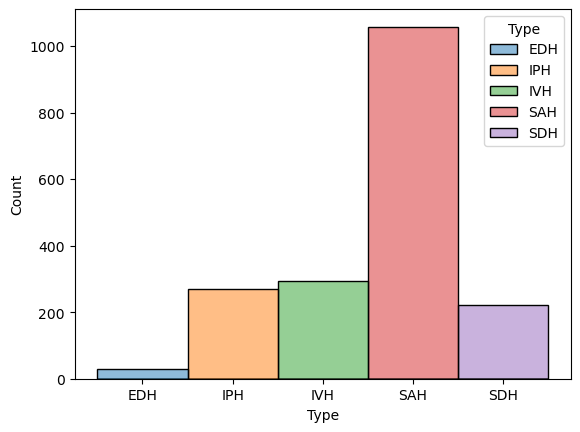

In [1]:
from pathlib import *
import nibabel as nib
import numpy as np
import pandas as pd
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('RSNA_BHSD_clusters.csv')

save_distributions=True

print(df)

plt.figure()
sns.histplot(data=df, x="Type", hue="Type", legend=True)

<Axes: xlabel='Mean_HU', ylabel='Density'>

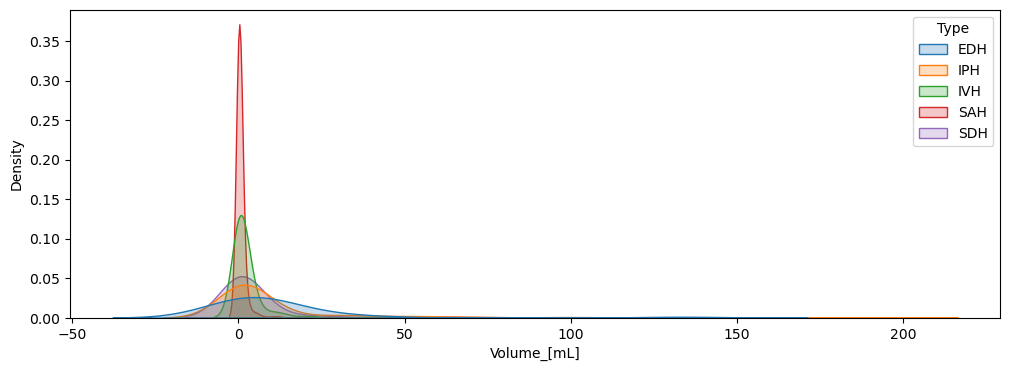

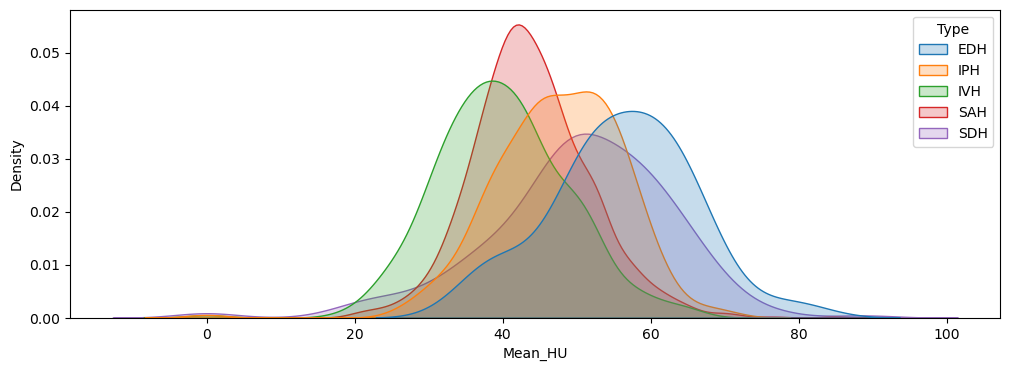

In [2]:

plt.figure(figsize=(12, 4))
sns.kdeplot(data=df, x="Volume_[mL]", hue="Type", legend=True, common_norm=False, fill=True)

plt.figure(figsize=(12, 4))
sns.kdeplot(data=df, x="Mean_HU", hue="Type", legend=True, common_norm=False, fill=True)

# PROCESSING AND FITTING VOLUME KDE

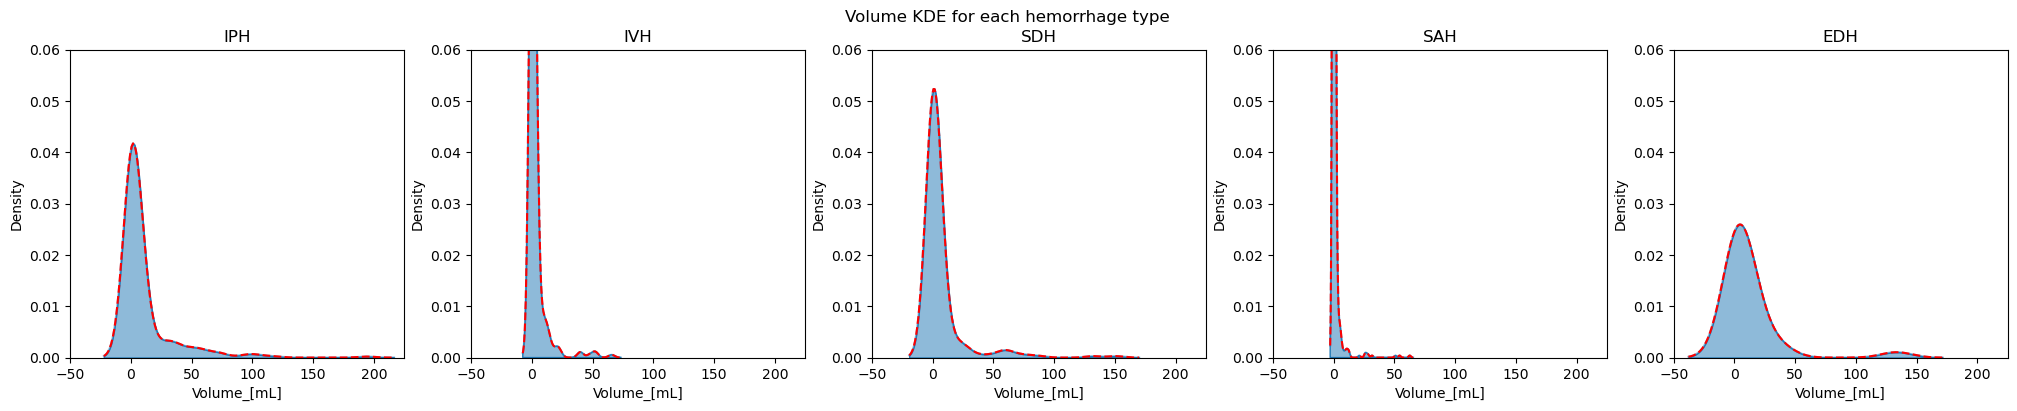

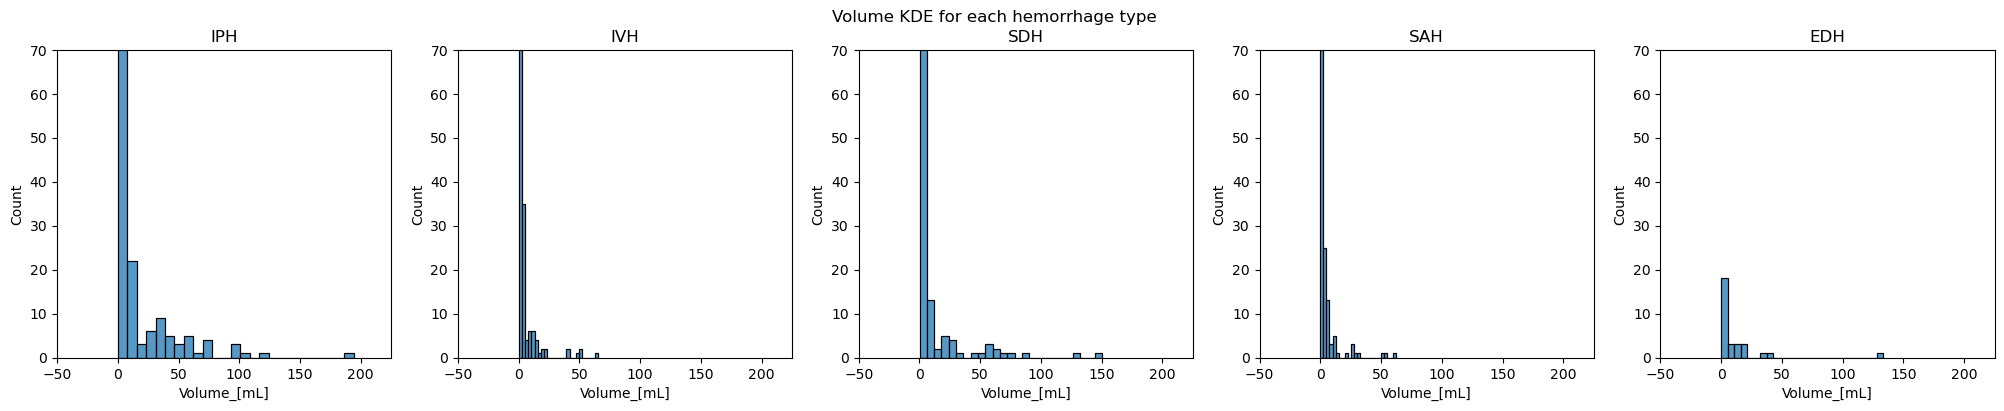

In [3]:
# KDES
fig, axes = plt.subplots(1, 5, figsize=(25,4))
fig.suptitle('Volume KDE for each hemorrhage type')
axes[0].set_title('IPH')
sns.kdeplot(ax=axes[0], data=df.loc[df['Type'] == 'IPH'], x="Volume_[mL]", fill=True, alpha=0.5, thresh=0.02)
x_IPH, y_IPH = sns.kdeplot(ax=axes[0], data=df.loc[df['Type'] == 'IPH'], x="Volume_[mL]", alpha=0.5, thresh=0.02).lines[0].get_data()
axes[0].plot(x_IPH, y_IPH, '--r')

axes[1].set_title('IVH')
sns.kdeplot(ax=axes[1], data=df.loc[df['Type'] == 'IVH'], x="Volume_[mL]", fill=True, alpha=0.5)
x_IVH, y_IVH = sns.kdeplot(ax=axes[1], data=df.loc[df['Type'] == 'IVH'], x="Volume_[mL]", alpha=0.5, thresh=0.02).lines[0].get_data()
axes[1].plot(x_IVH, y_IVH, '--r')

axes[2].set_title('SDH')
sns.kdeplot(ax=axes[2], data=df.loc[df['Type'] == 'SDH'], x="Volume_[mL]", fill=True, alpha=0.5)
x_SDH, y_SDH = sns.kdeplot(ax=axes[2], data=df.loc[df['Type'] == 'SDH'], x="Volume_[mL]", alpha=0.5, thresh=0.02).lines[0].get_data()
axes[2].plot(x_SDH, y_SDH, '--r')

axes[3].set_title('SAH')
sns.kdeplot(ax=axes[3], data=df.loc[df['Type'] == 'SAH'], x="Volume_[mL]", fill=True, alpha=0.5)
x_SAH, y_SAH = sns.kdeplot(ax=axes[3], data=df.loc[df['Type'] == 'SAH'], x="Volume_[mL]", alpha=0.5, thresh=0.02).lines[0].get_data()
axes[3].plot(x_SAH, y_SAH, '--r')

axes[4].set_title('EDH')
sns.kdeplot(ax=axes[4], data=df.loc[df['Type'] == 'EDH'], x="Volume_[mL]", fill=True, alpha=0.5)
x_EDH, y_EDH = sns.kdeplot(ax=axes[4], data=df.loc[df['Type'] == 'EDH'], x="Volume_[mL]", alpha=0.5, thresh=0.02).lines[0].get_data()
axes[4].plot(x_EDH, y_EDH, '--r')

_ = plt.setp(axes, xlim=(-50,225), ylim=(0,0.06))

# HISTOGRAMS (for reference, fine-tuning KDE parameters)
fig, axes = plt.subplots(1, 5, figsize=(25,4))
fig.suptitle('Volume KDE for each hemorrhage type')
axes[0].set_title('IPH')
sns.histplot(ax=axes[0], data=df.loc[df['Type'] == 'IPH'], x="Volume_[mL]", bins=25)

axes[1].set_title('IVH')
sns.histplot(ax=axes[1], data=df.loc[df['Type'] == 'IVH'], x="Volume_[mL]", bins=25)

axes[2].set_title('SDH')
sns.histplot(ax=axes[2], data=df.loc[df['Type'] == 'SDH'], x="Volume_[mL]", bins=25)

axes[3].set_title('SAH')
sns.histplot(ax=axes[3], data=df.loc[df['Type'] == 'SAH'], x="Volume_[mL]", bins=25)

axes[4].set_title('EDH')
sns.histplot(ax=axes[4], data=df.loc[df['Type'] == 'EDH'], x="Volume_[mL]", bins=25)

_ = plt.setp(axes, xlim=(-50, 225), ylim=(0, 70))

Get rid of unrealistic volumes (i.e. below threshold close to 0) and add to dataframe

0      1.006511
1      2.057548
2      3.108586
3      4.159624
4      5.210661
         ...   
195    0.000000
196    0.000000
197    0.000000
198    0.000000
199    0.000000
Name: EDH_volume, Length: 200, dtype: float64
0      0.025086
1      0.025511
2      0.025792
3      0.025929
4      0.025920
         ...   
195    0.000000
196    0.000000
197    0.000000
198    0.000000
199    0.000000
Name: EDH_weight, Length: 200, dtype: float64


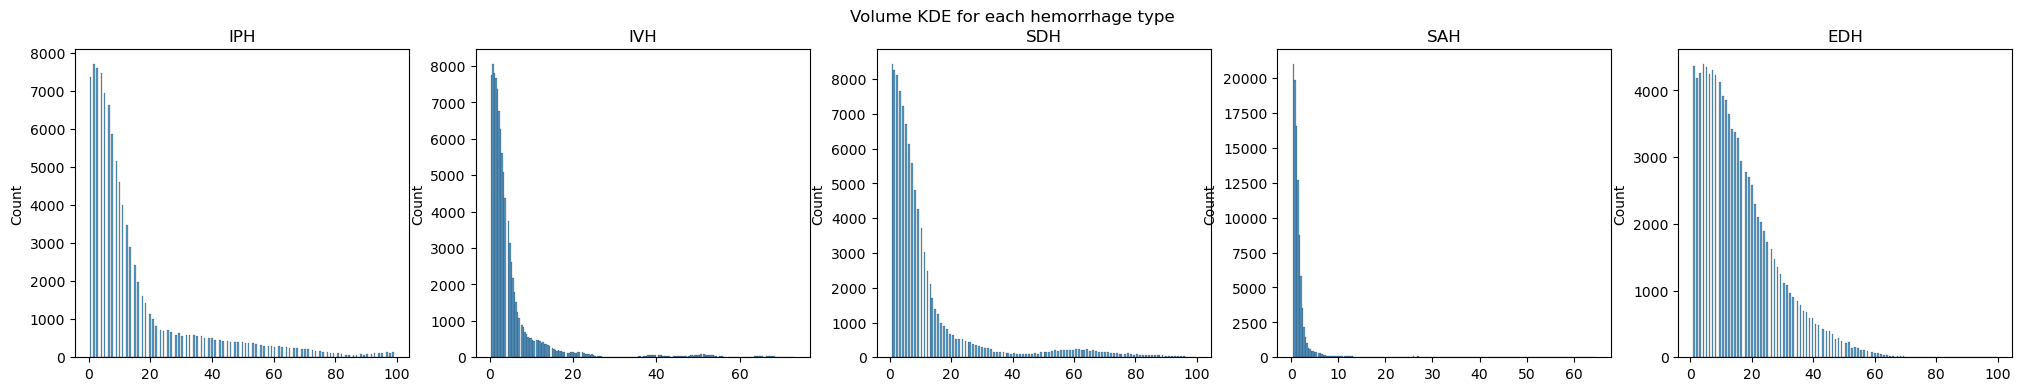

In [4]:
import random
kde_length = len(x_IPH)

df_volume = pd.DataFrame(columns=['IPH_volume', 'IPH_weight', 
                                  'IVH_volume', 'IVH_weight',
                                  'SDH_volume', 'SDH_weight',
                                  'SAH_volume', 'SAH_weight',
                                  'EDH_volume', 'EDH_weight'])

min_volume = 0.01
max_volume = 100
IPH_max_volume = 100

df_volume['IPH_volume'] = np.pad(x_IPH[np.where((x_IPH > min_volume) & (x_IPH < IPH_max_volume))], (0, 200-len(x_IPH[np.where((x_IPH > min_volume) & (x_IPH < IPH_max_volume))])), 'constant')
df_volume['IPH_weight'] = np.pad(y_IPH[np.where((x_IPH > min_volume) & (x_IPH < IPH_max_volume))], (0, 200-len(x_IPH[np.where((x_IPH > min_volume) & (x_IPH < IPH_max_volume))])), 'constant')

df_volume['IVH_volume'] = np.pad(x_IVH[np.where((x_IVH > min_volume) & (x_IVH < max_volume))], (0, 200-len(x_IVH[np.where((x_IVH > min_volume) & (x_IVH < max_volume))])), 'constant')
df_volume['IVH_weight'] = np.pad(y_IVH[np.where((x_IVH > min_volume) & (x_IVH < max_volume))], (0, 200-len(x_IVH[np.where((x_IVH > min_volume) & (x_IVH < max_volume))])), 'constant')

df_volume['SDH_volume'] = np.pad(x_SDH[np.where((x_SDH > min_volume) & (x_SDH < max_volume))], (0, 200-len(x_SDH[np.where((x_SDH > min_volume) & (x_SDH < max_volume))])), 'constant')
df_volume['SDH_weight'] = np.pad(y_SDH[np.where((x_SDH > min_volume) & (x_SDH < max_volume))], (0, 200-len(x_SDH[np.where((x_SDH > min_volume) & (x_SDH < max_volume))])), 'constant')

df_volume['SAH_volume'] = np.pad(x_SAH[np.where((x_SAH > min_volume) & (x_SAH < max_volume))], (0, 200-len(x_SAH[np.where((x_SAH > min_volume) & (x_SAH < max_volume))])), 'constant')
df_volume['SAH_weight'] = np.pad(y_SAH[np.where((x_SAH > min_volume) & (x_SAH < max_volume))], (0, 200-len(x_SAH[np.where((x_SAH > min_volume) & (x_SAH < max_volume))])), 'constant')

df_volume['EDH_volume'] = np.pad(x_EDH[np.where((x_EDH > min_volume) & (x_EDH < max_volume))], (0, 200-len(x_EDH[np.where((x_EDH > min_volume) & (x_EDH < max_volume))])), 'constant')
df_volume['EDH_weight'] = np.pad(y_EDH[np.where((x_EDH > min_volume) & (x_EDH < max_volume))], (0, 200-len(x_EDH[np.where((x_EDH > min_volume) & (x_EDH < max_volume))])), 'constant')

if save_distributions:
    df_volume.to_csv('../src/pedsilicoICH/distributions/BHSD_volume_distributions.csv')


test_IPH_sample = []
test_IVH_sample = []
test_SDH_sample = []
test_SAH_sample = []
test_EDH_sample = []

## optional: draw a bunch of samples and plot histograms:
for i in range(100000):
    test_IPH_sample.append(random.choices(df_volume['IPH_volume'], weights=df_volume['IPH_weight'])[0])
    test_IVH_sample.append(random.choices(df_volume['IVH_volume'], weights=df_volume['IVH_weight'])[0])
    test_SDH_sample.append(random.choices(df_volume['SDH_volume'], weights=df_volume['SDH_weight'])[0])
    test_SAH_sample.append(random.choices(df_volume['SAH_volume'], weights=df_volume['SAH_weight'])[0])
    test_EDH_sample.append(random.choices(df_volume['EDH_volume'], weights=df_volume['EDH_weight'])[0])

# HISTOGRAMS (for reference, fine-tuning KDE parameters)
fig, axes = plt.subplots(1, 5, figsize=(25,4))
fig.suptitle('Volume KDE for each hemorrhage type')
axes[0].set_title('IPH')
sns.histplot(ax=axes[0], x=test_IPH_sample, bins=len(df_volume['IPH_volume']))

axes[1].set_title('IVH')
sns.histplot(ax=axes[1], x=test_IVH_sample, bins=len(df_volume['IVH_volume']))

axes[2].set_title('SDH')
sns.histplot(ax=axes[2], x=test_SDH_sample, bins=len(df_volume['SDH_volume']))

axes[3].set_title('SAH')
sns.histplot(ax=axes[3], x=test_SAH_sample, bins=len(df_volume['SAH_volume']))

axes[4].set_title('EDH')
sns.histplot(ax=axes[4], x=test_EDH_sample, bins=len(df_volume['EDH_volume']))

print(df_volume['EDH_volume'])
print(df_volume['EDH_weight'])


### PROCESSING AND FITTING MEAN HU KDES

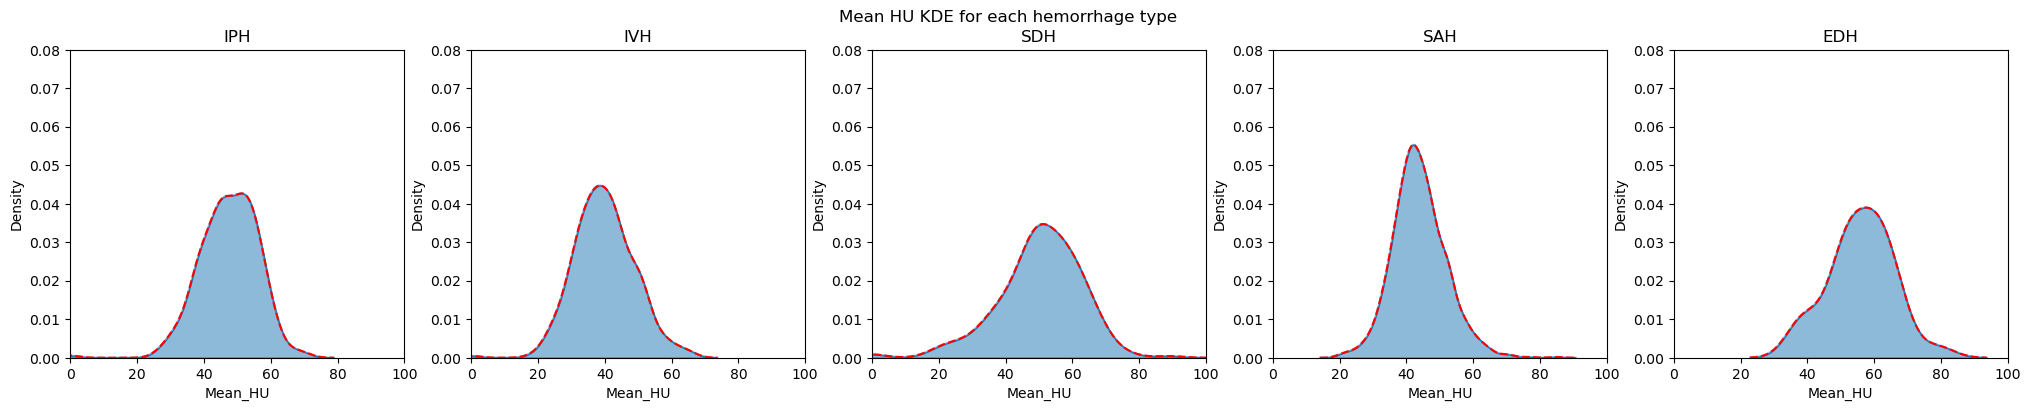

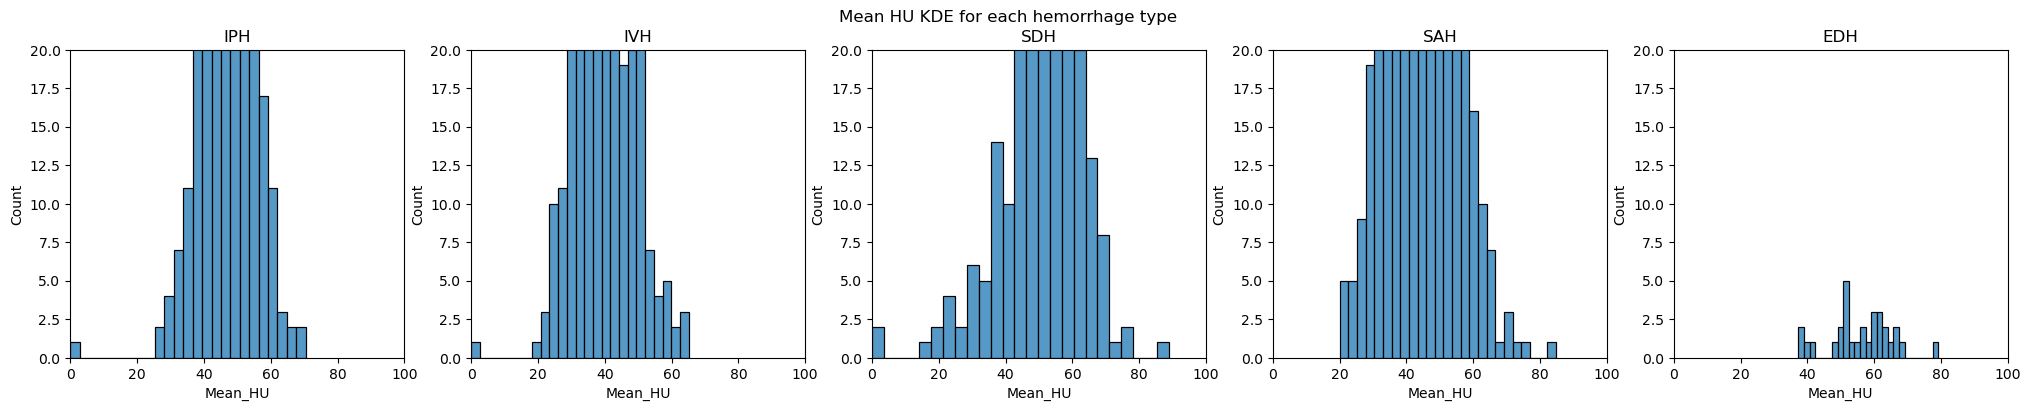

In [7]:
# KDES
fig, axes = plt.subplots(1, 5, figsize=(25,4))
fig.suptitle('Mean HU KDE for each hemorrhage type')
axes[0].set_title('IPH')
sns.kdeplot(ax=axes[0], data=df.loc[df['Type'] == 'IPH'], x="Mean_HU", fill=True, alpha=0.5, thresh=0.02)
hu_IPH, den_IPH = sns.kdeplot(ax=axes[0], data=df.loc[df['Type'] == 'IPH'], x="Mean_HU", alpha=0.5, thresh=0.02).lines[0].get_data()
axes[0].plot(hu_IPH, den_IPH, '--r')

axes[1].set_title('IVH')
sns.kdeplot(ax=axes[1], data=df.loc[df['Type'] == 'IVH'], x="Mean_HU", fill=True, alpha=0.5)
hu_IVH, den_IVH = sns.kdeplot(ax=axes[1], data=df.loc[df['Type'] == 'IVH'], x="Mean_HU", alpha=0.5, thresh=0.02).lines[0].get_data()
axes[1].plot(hu_IVH, den_IVH, '--r')

axes[2].set_title('SDH')
sns.kdeplot(ax=axes[2], data=df.loc[df['Type'] == 'SDH'], x="Mean_HU", fill=True, alpha=0.5)
hu_SDH, den_SDH = sns.kdeplot(ax=axes[2], data=df.loc[df['Type'] == 'SDH'], x="Mean_HU", alpha=0.5, thresh=0.02).lines[0].get_data()
axes[2].plot(hu_SDH, den_SDH, '--r')

axes[3].set_title('SAH')
sns.kdeplot(ax=axes[3], data=df.loc[df['Type'] == 'SAH'], x="Mean_HU", fill=True, alpha=0.5)
hu_SAH, den_SAH = sns.kdeplot(ax=axes[3], data=df.loc[df['Type'] == 'SAH'], x="Mean_HU", alpha=0.5, thresh=0.02).lines[0].get_data()
axes[3].plot(hu_SAH, den_SAH, '--r')

axes[4].set_title('EDH')
sns.kdeplot(ax=axes[4], data=df.loc[df['Type'] == 'EDH'], x="Mean_HU", fill=True, alpha=0.5)
hu_EDH, den_EDH = sns.kdeplot(ax=axes[4], data=df.loc[df['Type'] == 'EDH'], x="Mean_HU", alpha=0.5, thresh=0.02).lines[0].get_data()
axes[4].plot(hu_EDH, den_EDH, '--r')

_ = plt.setp(axes, xlim=(0, 100), ylim=(0,0.08))

# HISTOGRAMS (for reference, fine-tuning KDE parameters)
fig, axes = plt.subplots(1, 5, figsize=(25,4))
fig.suptitle('Mean HU KDE for each hemorrhage type')
axes[0].set_title('IPH')
sns.histplot(ax=axes[0], data=df.loc[df['Type'] == 'IPH'], x="Mean_HU", bins=25)

axes[1].set_title('IVH')
sns.histplot(ax=axes[1], data=df.loc[df['Type'] == 'IVH'], x="Mean_HU", bins=25)

axes[2].set_title('SDH')
sns.histplot(ax=axes[2], data=df.loc[df['Type'] == 'SDH'], x="Mean_HU", bins=25)

axes[3].set_title('SAH')
sns.histplot(ax=axes[3], data=df.loc[df['Type'] == 'SAH'], x="Mean_HU", bins=25)

axes[4].set_title('EDH')
sns.histplot(ax=axes[4], data=df.loc[df['Type'] == 'EDH'], x="Mean_HU", bins=25)

_ = plt.setp(axes, xlim=(0, 100), ylim=(0, 20))

<Axes: title={'center': 'EDH'}, ylabel='Count'>

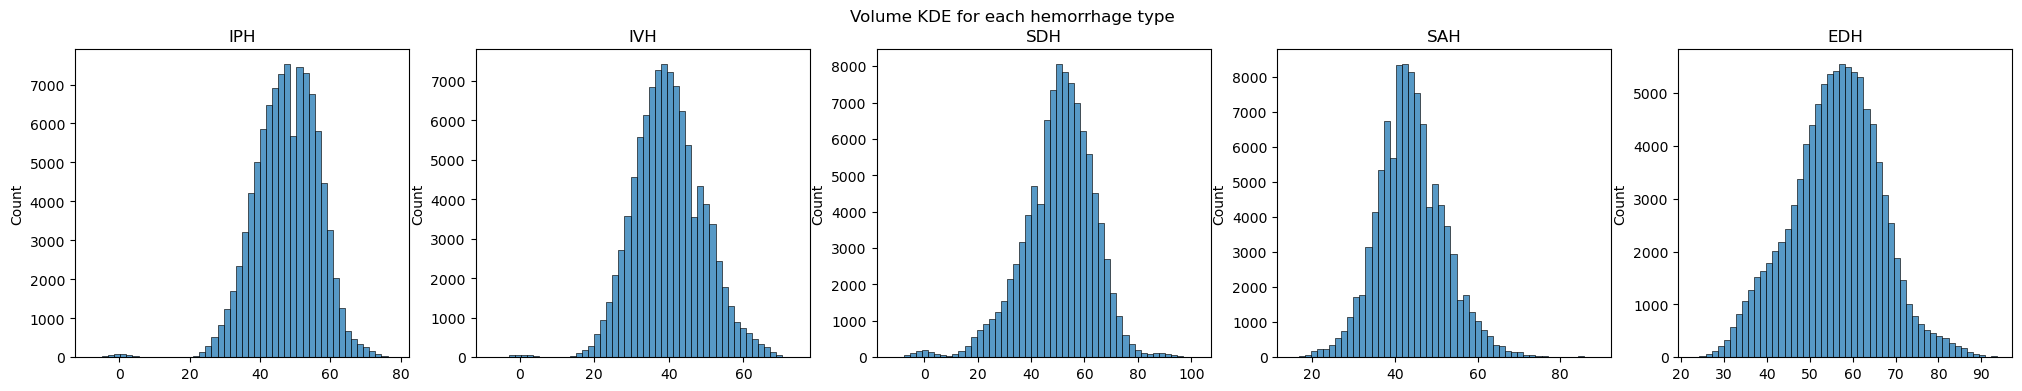

In [8]:
df_IPH_HU = pd.DataFrame(columns=['HU', 'weight'])
df_IVH_HU = pd.DataFrame(columns=['HU', 'weight'])
df_SDH_HU = pd.DataFrame(columns=['HU', 'weight'])
df_SAH_HU = pd.DataFrame(columns=['HU', 'weight'])
df_EDH_HU = pd.DataFrame(columns=['HU', 'weight'])

df_HU = pd.DataFrame(columns=['IPH_HU', 'IPH_weight', 
                                  'IVH_HU', 'IVH_weight',
                                  'SDH_HU', 'SDH_weight',
                                  'SAH_HU', 'SAH_weight',
                                  'EDH_HU', 'EDH_weight'])

min_volume = 0.01

df_HU['IPH_HU'] = hu_IPH
df_HU['IPH_weight'] = den_IPH

df_HU['IVH_HU'] = hu_IVH
df_HU['IVH_weight'] = den_IVH

df_HU['SDH_HU'] = hu_SDH
df_HU['SDH_weight'] = den_SDH

df_HU['SAH_HU'] = hu_SAH
df_HU['SAH_weight'] = den_SAH

df_HU['EDH_HU'] = hu_EDH
df_HU['EDH_weight'] = den_EDH

if save_distributions:
    df_HU.to_csv('../src/pedsilicoICH/distributions/BHSD_HU_distributions.csv')

test_IPH_sample = []
test_IVH_sample = []
test_SDH_sample = []
test_SAH_sample = []
test_EDH_sample = []

## optional: draw a bunch of samples and plot histograms:
for i in range(100000):
    test_IPH_sample.append(random.choices(df_HU['IPH_HU'], weights=df_HU['IPH_weight'])[0])
    test_IVH_sample.append(random.choices(df_HU['IVH_HU'], weights=df_HU['IVH_weight'])[0])
    test_SDH_sample.append(random.choices(df_HU['SDH_HU'], weights=df_HU['SDH_weight'])[0])
    test_SAH_sample.append(random.choices(df_HU['SAH_HU'], weights=df_HU['SAH_weight'])[0])
    test_EDH_sample.append(random.choices(df_HU['EDH_HU'], weights=df_HU['EDH_weight'])[0])

# HISTOGRAMS (for reference, fine-tuning KDE parameters)
fig, axes = plt.subplots(1, 5, figsize=(25,4))
fig.suptitle('Volume KDE for each hemorrhage type')
axes[0].set_title('IPH')
sns.histplot(ax=axes[0], x=test_IPH_sample, bins=50)

axes[1].set_title('IVH')
sns.histplot(ax=axes[1], x=test_IVH_sample, bins=50)

axes[2].set_title('SDH')
sns.histplot(ax=axes[2], x=test_SDH_sample, bins=50)

axes[3].set_title('SAH')
sns.histplot(ax=axes[3], x=test_SAH_sample, bins=50)

axes[4].set_title('EDH')
sns.histplot(ax=axes[4], x=test_EDH_sample, bins=50)